In [1]:
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris, load_wine
import warnings
import platform

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
df_c = pd.read_csv("../data/olist_customers_dataset.csv")
df_g = pd.read_csv("../data/olist_geolocation_dataset.csv")
df_oi = pd.read_csv("../data/olist_order_items_dataset.csv")
df_op = pd.read_csv("../data/olist_order_payments_dataset.csv")
df_or = pd.read_csv("../data/olist_order_reviews_dataset.csv")
df_o = pd.read_csv("../data/olist_orders_dataset.csv")
df_p = pd.read_csv("../data/olist_products_dataset.csv")
df_s = pd.read_csv("../data/olist_sellers_dataset.csv")

---
# 1. Seller 지역 분포 검정

- SP에 seller가 매우 많고 일부 지역에 seller가 집중되어있음
    - 단순한 데이터 특징인지, 통계적으로 의미 있는 차이인지 검정

- 귀무가설(H0): seller는 모든 state에 균등하게 분포한다
- 대립가설(H1): seller 분포가 균등하지 않다

In [48]:
seller_state_count = df_s['seller_state'].value_counts()

In [49]:
from scipy.stats import chisquare

observed = seller_state_count.values

expected = np.repeat(
    observed.sum() / len(observed),
    len(observed)
)

chi2, p = chisquare(f_obs=observed, f_exp=expected)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 24295.993537964467
p-value: 0.0


> **Chi-square: 24295** -> 실제 분포와 기대 분포의 차이가 매우 크다 <br>
> **p-value: 0.0** -> seller는 지역에 균등하게 분포하지 않는다

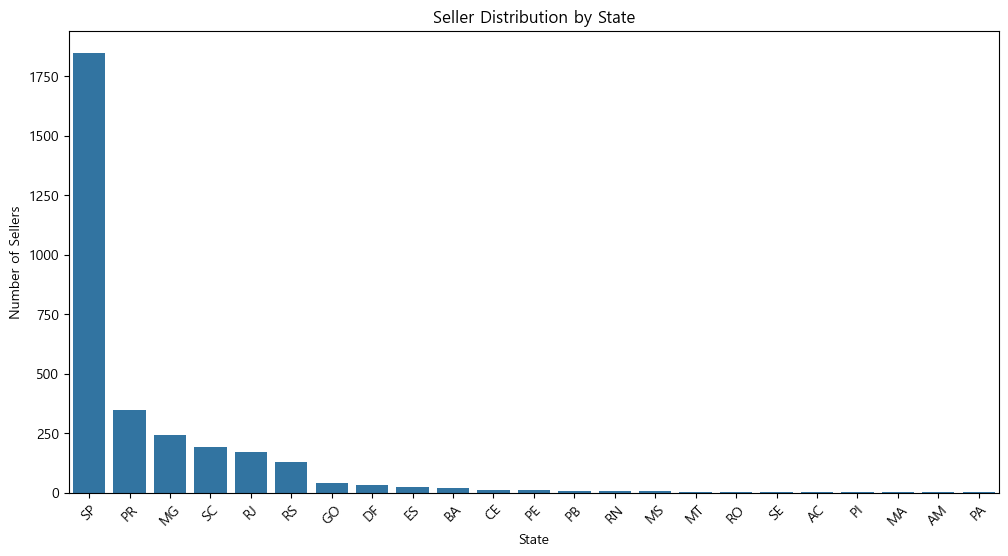

In [50]:
seller_state_count = df_s['seller_state'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=seller_state_count.index,
    y=seller_state_count.values
)

plt.title("Seller Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Sellers")

plt.xticks(rotation=45)

plt.show()

---
# 2. Seller vs Customer 분포 차이 검정

- seller의 지역 분포와 customer의 지역 분포는 동일한 구조인가?

- 귀무가설(H0): seller 분포와 customer 분포는 서로 독립이며, 분포에 차이가 없다
- 대립가설(H1): seller 분포와 customer 분포는 서로 독립이 아니며, 지역 분포에 차이가 있다

In [9]:
seller_state_count = df_s['seller_state'].value_counts().sort_index()
customer_state_count = df_c['customer_state'].value_counts().sort_index()

In [12]:
from scipy.stats import chi2_contingency

# table 생성
table = pd.concat([seller_state_count, customer_state_count], axis=1)
table.columns = ['seller','customer']
table = table.fillna(0).astype(int)

# chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 997.3245871934249
p-value: 1.3728272031523969e-193
Degrees of freedom: 26


> **Chi-square: 997.32** → Seller 분포와 Customer 분포 사이의 차이가 매우 크다  
> **p-value: 1.37e-193** → Seller의 지역 분포와 Customer의 지역 분포는 동일하지 않다

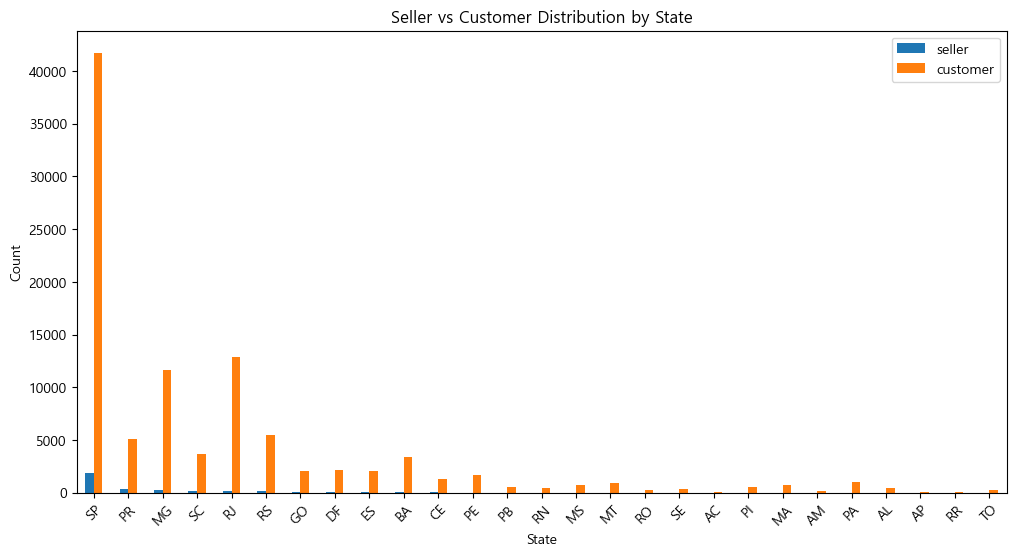

In [51]:
compare_df = pd.concat(
    [seller_state_count, customer_state_count],
    axis=1
)

compare_df.columns = [
    'seller',
    'customer'
]

compare_df.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Seller vs Customer Distribution by State")
plt.xlabel("State")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

---
# 3. Region × Category 연관성 검정

- seller의 지역과 판매 상품 카테고리는 서로 연관이 있는가?

- 귀무가설(H0): seller_state와 product_category는 서로 독립이다
- 대립가설(H1): seller_state와 product_category는 서로 연관이 있다

In [29]:
df = df_oi.merge(df_p, on="product_id")
df = df.merge(df_s, on="seller_id")

In [30]:
# contingency = pd.crosstab(
#     df['seller_state'],
#     df['product_category_name']
# )

top_categories = df['product_category_name'].value_counts().head(10).index
df_top = df[df['product_category_name'].isin(top_categories)]

contingency = pd.crosstab(df_top['seller_state'], df_top['product_category_name'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 26345.030815203798
p-value: 0.0
Degrees of freedom: 189


> **Chi-square: 26345.03** → 지역과 상품 카테고리 간 분포 차이가 매우 크게 나타남  
> **p-value: 0.0** → 지역과 상품 카테고리는 서로 독립적이지 않음

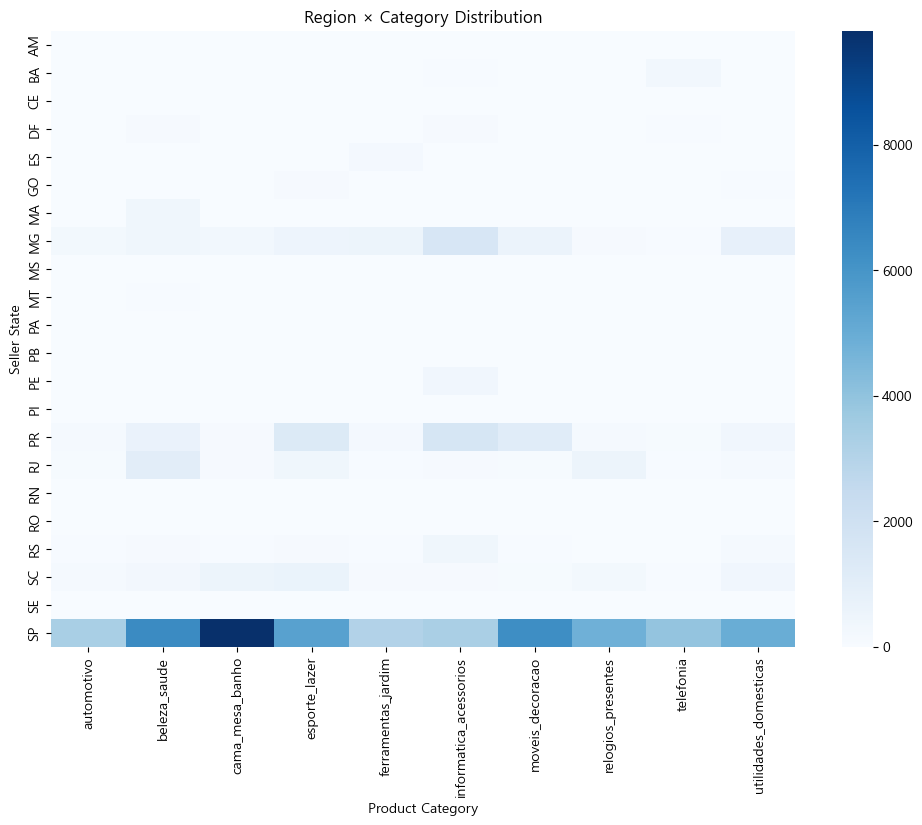

In [31]:
# Top 10 category 선택
top_categories = df['product_category_name'].value_counts().head(10).index
df_top = df[df['product_category_name'].isin(top_categories)]

# 교차표 생성
contingency = pd.crosstab(
    df_top['seller_state'],
    df_top['product_category_name']
)

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(contingency, cmap="Blues")

plt.title("Region × Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Seller State")

plt.show()

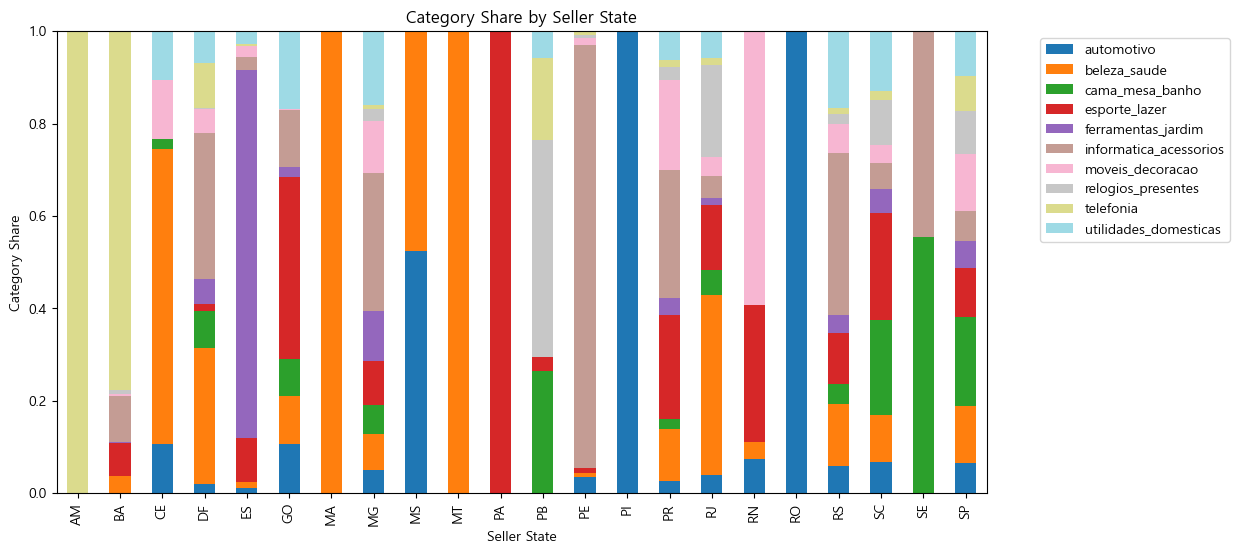

In [32]:
# 지역별 비율 계산
ratio = contingency.div(contingency.sum(axis=1), axis=0)

# stacked bar chart
ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="tab20"
)

plt.title("Category Share by Seller State")
plt.xlabel("Seller State")
plt.ylabel("Category Share")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.show()

---
# 4. Seller 활동량 지역 차이 검정

- seller의 활동량이 지역에 따라 차이가 있는가?

- 귀무가설(H0): 모든 지역의 seller 활동량 평균은 같다
- 대립가설(H1): 지역에 따라 seller 활동량 평균이 다르다

In [33]:
df = df_oi.merge(
    df_s[['seller_id','seller_state']],
    on='seller_id'
)

In [34]:
from scipy.stats import f_oneway

seller_activity = df.groupby(
    ['seller_id','seller_state']
)['order_id'].count().reset_index()

seller_activity.columns = [
    'seller_id',
    'seller_state',
    'order_count'
]

groups = [
    group['order_count'].values
    for name, group in seller_activity.groupby('seller_state')
]

f_stat, p = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p)

F-statistic: 1.4173338834845592
p-value: 0.09358594282803706


> **F-statistic: 1.42** → 지역 간 seller 활동량 평균 차이가 크지 않음  
> **p-value: 0.0936** → seller 활동량 평균은 지역에 따라 통계적으로 유의미한 차이가 있다고 보기 어려움

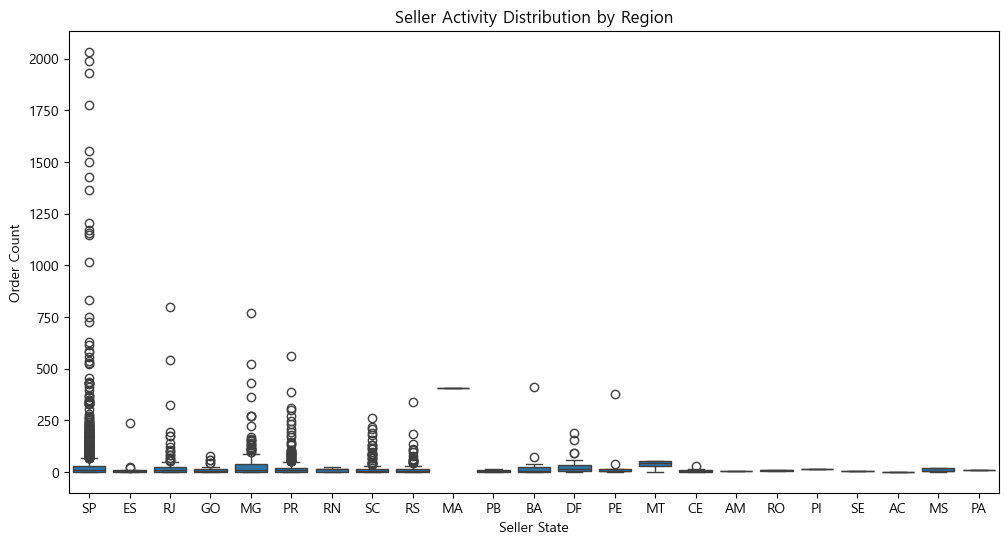

In [35]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='seller_state',
    y='order_count',
    data=seller_activity
)

plt.title("Seller Activity Distribution by Region")
plt.xlabel("Seller State")
plt.ylabel("Order Count")

plt.show()

---